<a href="https://colab.research.google.com/github/MIS520/Week2-DataPreprocessing/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 2: Data Cleaning and Pre-processing

In [6]:
# Cloning repo
!git clone https://github.com/MIS520/Week2-DataPreprocessing.git

Cloning into 'Week2-DataPreprocessing'...
remote: Enumerating objects: 3157, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 3157 (delta 20), reused 17 (delta 12), pack-reused 3118 (from 1)
Receiving objects: 100% (3157/3157), 480.02 MiB | 22.65 MiB/s, done.
Resolving deltas: 100% (275/275), done.
Updating files: 100% (4492/4492), done.


**Filename identifiers**

Modality (01 = full-AV, 02 = video-only, 03 = audio-only).

Vocal channel (01 = speech, 02 = song).

Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).

Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.

Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").

Repetition (01 = 1st repetition, 02 = 2nd repetition).

Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Importing Libraries

In [34]:
#importing the required libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa.display
import soundfile
import os

from glob import glob

import librosa
import IPython.display as ipd

def get_features(file_path, n_mfcc=40):
    '''Function to extract MFCC features from an audio file.'''
    with soundfile.SoundFile(file_path) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate = sound_file.samplerate
    # If audio is mono, reshape to 2D for librosa
    if X.ndim == 1: # check if mono, process as mono
        mfccs = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=n_mfcc)
    else:
        mfccs = librosa.feature.mfcc(y=X[:,0], sr=sample_rate, n_mfcc=n_mfcc) # Process first channel if stereo
    return np.mean(mfccs.T, axis=0)

## RAVDESS: Load dataset + set feature dictionary

In [8]:
audio_files = glob('/content/Week2-DataPreprocessing/data/Audio Data/*/*.wav') #collect every file that ends in WAV


#Playing an audio file using IPython.display
ipd.Audio(audio_files[0])

In [9]:
#Emotions in the RAVDESS dataset, assigning labels to the numbers in a dictionary
emotions_dict ={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

# Gender mapping based on actor number (01 to 24: Odd = male, Even = female)
gender_dict = {}
for i in range(1, 27): # Extended to include actor 26
    actor_code = f'{i:02d}' # Format as '01', '02', etc.
    if i % 2 == 1: # Odd
        gender_dict[actor_code] = 'male'
    else: # Even
        gender_dict[actor_code] = 'female'

In [10]:
#load + extract emotion
import os, glob

#read labels from each file
def load_data():
    X,y=[],[]
    count = 0
    for file in glob.glob("/content/Week2-DataPreprocessing/data/Audio Data/Actor_*/*.wav"):
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1440} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [11]:
features, emotions = load_data()

 Processed 1439/1440 audio samples 

### RAVDESS Data analysis - labels

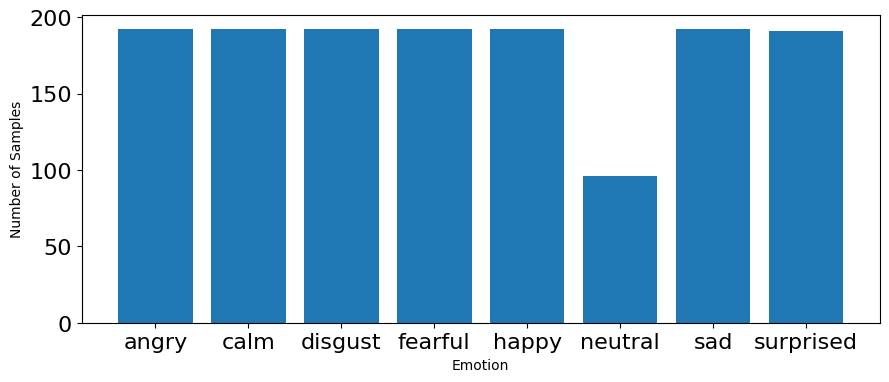

In [12]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.show()

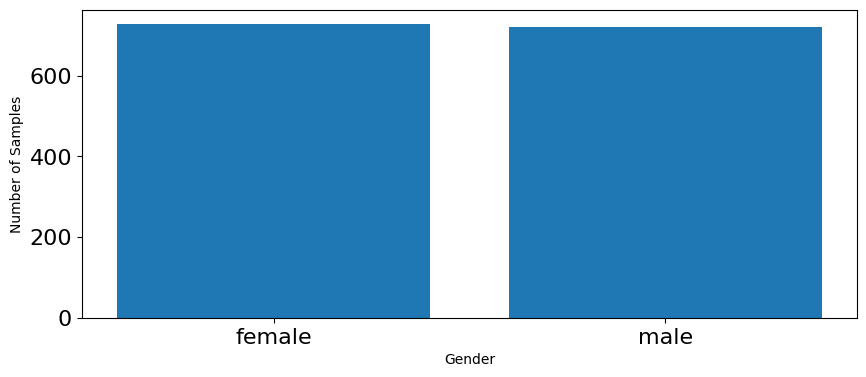

In [38]:
# plot genders
plt.figure(figsize=(10,4))
plt.subplot(1,1,1)
#np.unique returns ordered list of unique elements and count of each element
gender_list, count = np.unique(genders, return_counts=True)
plt.bar(x=range(len(gender_list)), height=count)
plt.xticks(ticks=range(len(gender_list)), labels = [gender for gender in gender_list],fontsize=10)
plt.xlabel('Gender')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.show()

## My Samples

### Update local repository from GitHub

In [13]:
# Navigate to the repository directory and pull the latest changes
%cd /content/Week2-DataPreprocessing
!git pull

# Navigate back to the root content directory (optional, but good practice)
#%cd /content

/content/Week2-DataPreprocessing
Already up to date.


In [18]:
audio_files2 = glob.glob('/content/Week2-DataPreprocessing/Actor 26/*.wav') #collect every file that ends in WAV


#Playing an audio file using IPython.display
ipd.Audio(audio_files2[0])

In [19]:
#load + extract emotion
import os, glob

#read labels from each file
def load_data():
    X,y=[],[]
    count = 0
    for file in glob.glob("/content/Week2-DataPreprocessing/Actor 26/*.wav"):
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1440} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [20]:
features, emotions = load_data()

 Processed 8/1440 audio samples 

### My Samples' Data Analysis - Labels

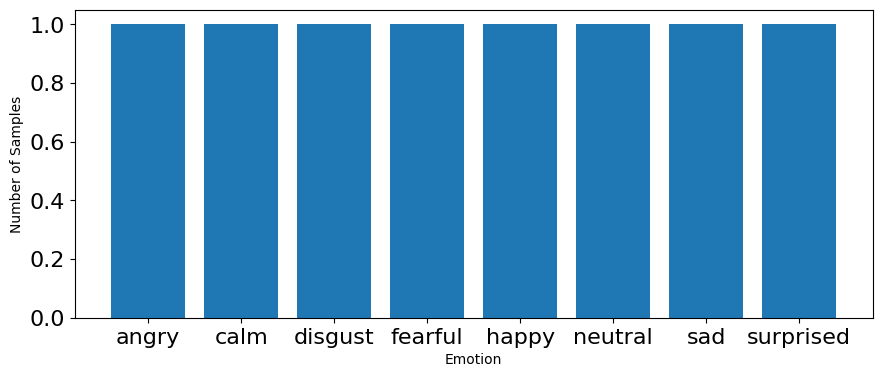

In [21]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.show()

## Combined Audio Dataset

In [22]:
#combined dataset
audio_files3 = glob.glob('/content/Week2-DataPreprocessing/data/Combined Audio Data/*/*.wav') #collect every file that ends in WAV


#Playing an audio file using IPython.display
ipd.Audio(audio_files3[0])

In [25]:
#Emotions in the RAVDESS dataset, assigning labels to the numbers in a dictionary
emotions_dict ={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

# Gender mapping based on actor number (01 to 24: Odd = male, Even = female)
gender_dict = {}
for i in range(1, 27): # Extended to include actor 26
    actor_code = f'{i:02d}' # Format as '01', '02', etc.
    if i % 2 == 1: # Odd
        gender_dict[actor_code] = 'male'
    else: # Even
        gender_dict[actor_code] = 'female'

In [35]:
#load + extract emotion and gender
import os, glob
import numpy as np # Ensure numpy is imported for array operations

#read labels from each file
def load_data():
    X_features,y_labels=[],[] # Renamed X to X_features and y to y_labels for clarity
    count = 0
    all_files = glob.glob("/content/Week2-DataPreprocessing/data/Audio Data/Actor_*/*.wav") # Changed to process the full dataset
    total_files = len(all_files) # Dynamically calculate total_files
    for file in all_files:
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        actor_code=file_name.split("-")[6].split(".")[0] # Extract actor code and remove .wav extension
        gender=gender_dict[actor_code] # Get gender from gender_dict
        features = get_features(file) # Uncommented and will now call get_features
        X_features.append(features) # Uncommented and will now append features
        y_labels.append((emotion, gender)) # Append both emotion and gender
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{total_files} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X_features), np.array(y_labels)

In [36]:
features, labels_combined = load_data()
emotions = labels_combined[:, 0]
genders = labels_combined[:, 1]

 Processed 1447/1440 audio samples 

## Combined Audio Data Analysis - Emotion and Gender

## Emotion

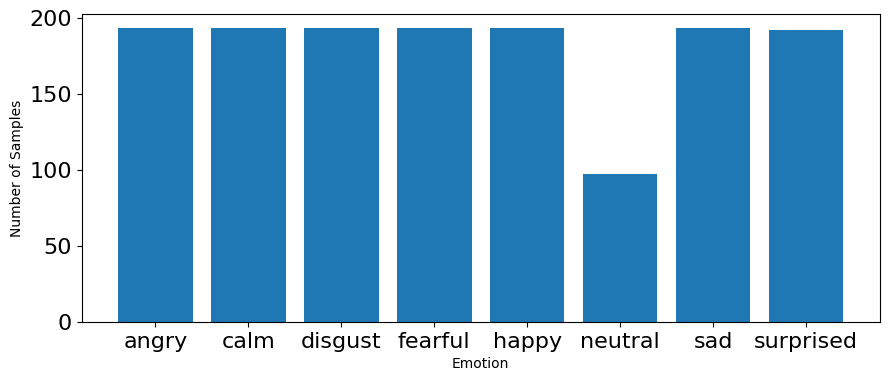

In [33]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.show()

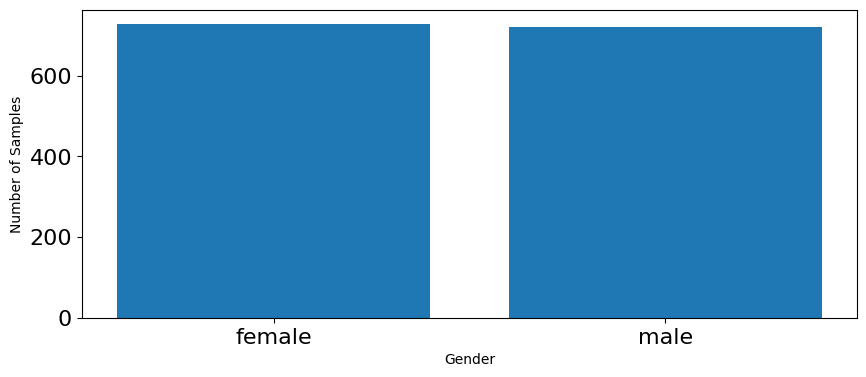

In [37]:
# plot genders
plt.figure(figsize=(10,4))
plt.subplot(1,1,1)
#np.unique returns ordered list of unique elements and count of each element
gender_list, count = np.unique(genders, return_counts=True)
plt.bar(x=range(len(gender_list)), height=count)
plt.xticks(ticks=range(len(gender_list)), labels = [gender for gender in gender_list],fontsize=10)
plt.xlabel('Gender')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.show()